# 02 Exploratory Data Analysis

# Health Insurance Fraud Detection — Exploratory Data Analysis

## Executive objective

This notebook performs a rigorous exploratory analysis of supplementary health insurance reimbursement claims before feature engineering and model training.

The analysis is designed to answer five questions:

1. **What does the claim portfolio look like?**
2. **Which observable claim, customer, provider and historical patterns are associated with fraud?**
3. **Which unusual legitimate claims could become false positives?**
4. **Which candidate features appear informative, redundant, unstable or potentially dangerous?**
5. **What modeling and operational decisions follow from the evidence?**

The prediction unit is one reimbursement claim.

The target is:

\[
Y = \texttt{is\_fraud}\in\{0,1\}
\]

with the future model expected to estimate:

\[
P(Y=1\mid X_t)
\]

using only information available at the claim scoring timestamp.

> **Important:** synthetic ground-truth metadata may be used for diagnostic analysis in this notebook, but must never enter the predictive feature matrix.

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "interim"

CLAIMS_PATH = DATA_DIR / "claims.parquet"
CUSTOMERS_PATH = DATA_DIR / "customers.parquet"
PROVIDERS_PATH = DATA_DIR / "providers.parquet"
POLICIES_PATH = DATA_DIR / "policies.parquet"

FIGURES_DIR = PROJECT_ROOT / "artifacts" / "metadata" / "eda_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /workspaces/Fraud-risk-model
Data directory: /workspaces/Fraud-risk-model/data/interim


In [5]:
claims = pd.read_parquet(CLAIMS_PATH)
customers = pd.read_parquet(CUSTOMERS_PATH)
providers = pd.read_parquet(PROVIDERS_PATH)
policies = pd.read_parquet(POLICIES_PATH)

tables = {
    "customers": customers,
    "providers": providers,
    "policies": policies,
    "claims": claims,
}

overview = pd.DataFrame(
    {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "memory_mb": df.memory_usage(index=True, deep=True).sum() / 1024**2,
    }
    for name, df in tables.items()
)

overview

,table,rows,columns,memory_mb
0,customers,20000,6,3.7574
1,providers,1200,6,0.2816
2,policies,20000,5,3.6386
3,claims,99888,55,112.8091


In [6]:
assert claims["claim_id"].is_unique
assert claims["is_fraud"].isin([0, 1]).all()

print(f"Claims:            {len(claims):,}")
print(f"Fraud cases:       {claims['is_fraud'].sum():,}")
print(f"Fraud prevalence:  {claims['is_fraud'].mean():.3%}")
print(f"First claim:       {claims['claim_submission_timestamp'].min()}")
print(f"Last claim:        {claims['claim_submission_timestamp'].max()}")

Claims:            99,888
Fraud cases:       2,482
Fraud prevalence:  2.485%
First claim:       2023-01-01 00:22:09
Last claim:        2026-06-30 23:58:50


## 2. Feature governance and leakage guardrails

The analytical table contains variables serving different purposes.  
They must not all be treated as model inputs.

### Direct identifiers
Useful for joins, temporal aggregation, investigation tracing and debugging, but excluded from the initial model.

### Synthetic ground-truth metadata
Generated only to inspect whether the synthetic world behaves as intended. These variables would not exist at scoring time in a real insurer.

### Synthetic profile variables
Used by the simulator to generate heterogeneous populations. They are conservatively excluded from the principal predictive model because they are not directly observable operational features.

### Candidate model features
Variables potentially available at scoring time, subject to temporal-leakage verification.

In [7]:
TARGET = "is_fraud"

IDENTIFIER_COLUMNS = [
    "claim_id",
    "customer_id",
    "policy_id",
    "provider_id",
]

LEAKAGE_COLUMNS = [
    "legitimate_anomaly",
    "legitimate_anomaly_type",
    "latent_fraud_score",
    "synthetic_fraud_probability",
    "fraud_difficulty",
    "fraud_mechanism",
]

SYNTHETIC_PROFILE_COLUMNS = [
    "customer_behavior_segment",
    "provider_behavior_segment",
]

EXCLUDED_FROM_MODEL = (
    IDENTIFIER_COLUMNS
    + LEAKAGE_COLUMNS
    + SYNTHETIC_PROFILE_COLUMNS
    + [TARGET]
)

candidate_features = [
    c for c in claims.columns
    if c not in EXCLUDED_FROM_MODEL
]

assert len(candidate_features) == 42

print(f"Total columns:            {claims.shape[1]}")
print(f"Candidate model features: {len(candidate_features)}")
print(f"Excluded columns:         {len(EXCLUDED_FROM_MODEL)}")

Total columns:            55
Candidate model features: 42
Excluded columns:         13


In [8]:
def save_figure(fig, name: str) -> None:
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")


def fraud_rate_table(
    df: pd.DataFrame,
    feature: str,
    min_count: int = 1,
) -> pd.DataFrame:
    out = (
        df.groupby(feature, dropna=False)[TARGET]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
        .reset_index()
    )
    out["fraud_rate_pct"] = out["fraud_rate"] * 100
    return out.loc[out["count"] >= min_count].sort_values(
        "fraud_rate",
        ascending=False,
    )


def plot_rate_by_category(
    df: pd.DataFrame,
    feature: str,
    title: str,
    min_count: int = 1,
    max_categories: int | None = None,
):
    table = fraud_rate_table(df, feature, min_count=min_count)

    if max_categories is not None:
        table = table.head(max_categories)

    table = table.sort_values("fraud_rate_pct")

    fig, ax = plt.subplots(figsize=(9, max(4.5, 0.45 * len(table))))
    ax.barh(table[feature].astype(str), table["fraud_rate_pct"])
    ax.axvline(df[TARGET].mean() * 100, linestyle="--", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    return fig, ax, table


def quantile_risk_table(
    df: pd.DataFrame,
    feature: str,
    q: int = 10,
) -> pd.DataFrame:
    work = df[[feature, TARGET]].dropna().copy()

    # rank first so qcut remains robust when many observations share the same value
    work["bucket"] = pd.qcut(
        work[feature].rank(method="first"),
        q=q,
        labels=False,
        duplicates="drop",
    )

    out = (
        work.groupby("bucket")
        .agg(
            count=(TARGET, "size"),
            fraud_count=(TARGET, "sum"),
            fraud_rate=(TARGET, "mean"),
            feature_min=(feature, "min"),
            feature_median=(feature, "median"),
            feature_max=(feature, "max"),
        )
        .reset_index()
    )
    out["fraud_rate_pct"] = out["fraud_rate"] * 100
    return out


def plot_quantile_risk(
    df: pd.DataFrame,
    feature: str,
    title: str,
    q: int = 10,
):
    table = quantile_risk_table(df, feature, q=q)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        table["bucket"] + 1,
        table["fraud_rate_pct"],
        marker="o",
    )
    ax.axhline(
        df[TARGET].mean() * 100,
        linestyle="--",
        linewidth=1.4,
    )
    ax.set_title(title)
    ax.set_xlabel(f"{feature} quantile")
    ax.set_ylabel("Fraud rate (%)")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    return fig, ax, table


def rank_biserial_from_u(
    u_statistic: float,
    n_fraud: int,
    n_legit: int,
) -> float:
    return 2 * u_statistic / (n_fraud * n_legit) - 1


def cramers_v(table: pd.DataFrame) -> float:
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = table.shape
    denominator = min(k - 1, r - 1)
    if denominator <= 0:
        return np.nan

    return float(np.sqrt((chi2 / n) / denominator))


def numeric_effect_table(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        fraud = df.loc[df[TARGET] == 1, feature].dropna()
        legit = df.loc[df[TARGET] == 0, feature].dropna()

        if len(fraud) == 0 or len(legit) == 0:
            continue

        u, p = mannwhitneyu(
            fraud,
            legit,
            alternative="two-sided",
            method="asymptotic",
        )

        effect = rank_biserial_from_u(
            u,
            len(fraud),
            len(legit),
        )

        rows.append(
            {
                "feature": feature,
                "legitimate_median": legit.median(),
                "fraud_median": fraud.median(),
                "median_difference": fraud.median() - legit.median(),
                "rank_biserial_effect": effect,
                "abs_effect": abs(effect),
                "p_value": p,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("abs_effect", ascending=False)
        .reset_index(drop=True)
    )


def categorical_effect_table(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        contingency = pd.crosstab(
            df[feature].fillna("__MISSING__"),
            df[TARGET],
        )

        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        chi2, p, _, _ = chi2_contingency(contingency)
        cv = cramers_v(contingency)

        rows.append(
            {
                "feature": feature,
                "levels": contingency.shape[0],
                "cramers_v": cv,
                "p_value": p,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )

# Part I — Portfolio and data quality

##  Missing-data profile

Missingness is not automatically a data-quality error.  
For this project, some missing values were deliberately retained because they may occur operationally.

We examine:

- magnitude of missingness;
- whether missingness itself is associated with fraud;
- whether explicit missing indicators may later be useful.

In [10]:
missing = pd.DataFrame(
    {
        "missing_count": claims.isna().sum(),
        "missing_pct": claims.isna().mean() * 100,
    }
)

missing = (
    missing.loc[missing["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing

,missing_count,missing_pct
customer_provider_claims_30d,99877,99.9890
days_since_same_provider_claim,99563,99.6746
same_service_claims_30d,97615,97.7245
customer_claims_7d,96578,96.6863
days_since_policy_change,91796,91.8989
customer_amount_30d,86780,86.8773
customer_claims_30d,86780,86.8773
customer_claims_90d,67185,67.2603
customer_amount_365d,30166,30.1998
customer_avg_claim_amount_365d,30166,30.1998


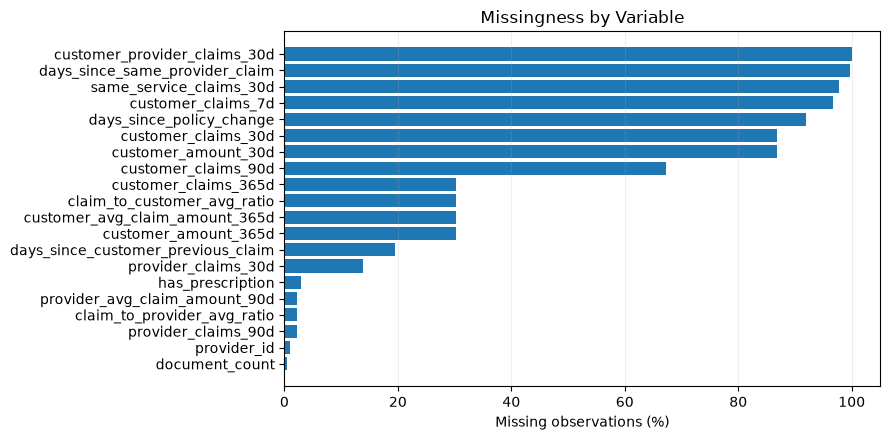

In [11]:
if not missing.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot_data = missing.sort_values("missing_pct")
    ax.barh(plot_data.index, plot_data["missing_pct"])
    ax.set_title("Missingness by Variable")
    ax.set_xlabel("Missing observations (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    save_figure(fig, "01_missingness")
    plt.show()

In [12]:
missing_risk_rows = []

for feature in missing.index:
    comparison = (
        claims.assign(is_missing=claims[feature].isna())
        .groupby("is_missing")[TARGET]
        .agg(["count", "mean"])
        .reset_index()
    )
    comparison["feature"] = feature
    comparison["fraud_rate_pct"] = comparison["mean"] * 100
    missing_risk_rows.append(comparison)

missing_risk = pd.concat(missing_risk_rows, ignore_index=True)

missing_risk[
    ["feature", "is_missing", "count", "fraud_rate_pct"]
].sort_values(["feature", "is_missing"])

,feature,is_missing,count,fraud_rate_pct
20,claim_to_customer_avg_ratio,False,69722,2.4368
21,claim_to_customer_avg_ratio,True,30166,2.5956
34,claim_to_provider_avg_ratio,False,97715,2.4868
35,claim_to_provider_avg_ratio,True,2173,2.3930
10,customer_amount_30d,False,13108,2.4565
11,customer_amount_30d,True,86780,2.4891
16,customer_amount_365d,False,69722,2.4368
17,customer_amount_365d,True,30166,2.5956
18,customer_avg_claim_amount_365d,False,69722,2.4368
19,customer_avg_claim_amount_365d,True,30166,2.5956


## . Target imbalance and naïve baseline

In [13]:
target_summary = (
    claims[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(claims) * 100
)

target_summary

,count,percentage
is_fraud,,
Legitimate,97406,97.5152
Fraud,2482,2.4848


### Interpretation

Because fraud is rare, accuracy is not an adequate primary model-selection metric.

Later modeling will emphasize:

- **PR-AUC / Average Precision**;
- precision and recall at selected operating points;
- calibration;
- **Precision@K / Recall@K** under constrained investigation capacity;
- captured fraud amount / expected value.

## . Portfolio composition

In [14]:
portfolio_metrics = pd.Series(
    {
        "claims": len(claims),
        "customers_in_claims": claims["customer_id"].nunique(),
        "providers_in_claims": claims["provider_id"].nunique(dropna=True),
        "policies_in_claims": claims["policy_id"].nunique(),
        "mean_claim_amount": claims["claim_amount"].mean(),
        "median_claim_amount": claims["claim_amount"].median(),
        "fraud_rate": claims[TARGET].mean(),
    }
)

portfolio_metrics

claims                99,888.0000
customers_in_claims   19,488.0000
providers_in_claims    1,199.0000
policies_in_claims    19,488.0000
mean_claim_amount        208.4216
median_claim_amount      143.1700
fraud_rate                 0.0248
dtype: float64